### [데이터 전처리 - 타겟 불균형 처리] <hr>

- **불균형 데이터란**
    * 타겟 클래스의 비율이 한쪽으로 크게 치우친 데이터
    * 예1) 정상 고객: 950명, 이탈 고객: 50명
    * 예2) 구매 안함: 900명, 구매 함: 100명

- **방식**
    * UpSampling
    * DownSampling
    * Class_Weight
    * SMOTE

- **[0] 모듈로딩**

In [2]:
## 데이터 분석 관련
import pandas as pd
import numpy as np

## 시각화 관련
import matplotlib.pyplot as plt

## ML 데이터셋 관련
from sklearn.utils import resample

## ML 모델 : class_weight 파라미터 존재
from sklearn.linear_model import LogisticRegression   

- **[1] 불균형 데이터 준비**

    * 파일명:imbalanced_data.csv
    * 타겟 컬럼 : target => target = 0 : 일반 클래스 | target = 1 : 소수 클래스

In [3]:
## 데이터 준비
DATA_FILE = '../Data/Numbers/imbalanced_data.csv'

## 데이터 로딩 => 첫번째 컬럼명, 쉼표로 데이터 구분
df = pd.read_csv(DATA_FILE)

In [4]:
## 기본 정보 확인
df.info()
display( df.head() )

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   city         500 non-null    str  
 1   grade        500 non-null    str  
 2   gender       500 non-null    str  
 3   age          500 non-null    int64
 4   visit_count  500 non-null    int64
 5   avg_price    500 non-null    int64
 6   target       500 non-null    int64
dtypes: int64(4), str(3)
memory usage: 27.5 KB


,city,grade,gender,age,visit_count,avg_price,target
0,부산,Silver,Male,21,5,322579,1
1,제주,Silver,Female,25,6,73965,0
2,대구,Bronze,Female,47,4,342066,0
3,대구,Gold,Female,48,8,107799,0
4,서울,Silver,Female,45,9,103948,0


- **[2] 클래스 비율 확인** 


In [5]:
##=> 클래스별 개수
df['target'].value_counts()

target
0    450
1     50
Name: count, dtype: int64

In [6]:
##=> 클래스별 비율
df['target'].value_counts(normalize=True)

target
0    0.9
1    0.1
Name: proportion, dtype: float64

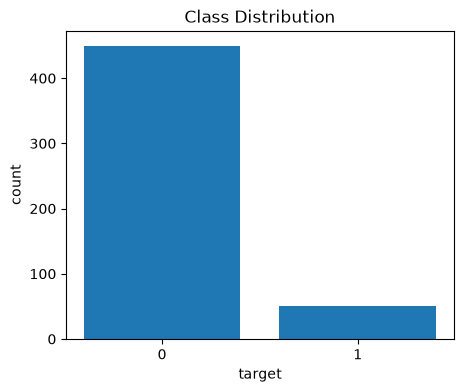

In [7]:
## => 시각화
class_counts = df['target'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel('target')
plt.ylabel('count')
plt.title('Class Distribution')
plt.show()

- **[3]불균형 데이터 전처리**

In [8]:
## -------------------------------------------
## 클래스별 데이터 분리
## -------------------------------------------
## =>  target == 0,  target == 1 
mask =  df['target'] == 0

majorDF = df[mask]
minorDF = df[~mask]

print(f'[Major Class] {majorDF.shape},  [Minor Class] {minorDF.shape}')

[Major Class] (450, 7),  [Minor Class] (50, 7)


In [9]:
## ----------------------------------------------------
## UpSampling : 소수 클래스 => 증가 
##              복원방식 샘플링 즉, 동일 데이터가 계속 추출
## - 단점 : 동일 데이터가 존재 => 과대적합 우려
## ----------------------------------------------------
minorUpDF = resample(minorDF, 
                     replace=True,                  ##<- 복원 방식
                     n_samples=majorDF.shape[0],    ##<- 다수 클래스 개수만큼
                     random_state=10)

print(f'[Minor Class] {minorDF.shape}  =>  [minorUpDF] {minorUpDF.shape}')

## MajorDF와 합치기
totalDF = pd.concat([majorDF, minorUpDF])

print(f'[totalDF] {totalDF.shape}')
print(f'[Target ] {totalDF["target"].value_counts()}')

[Minor Class] (50, 7)  =>  [minorUpDF] (450, 7)
[totalDF] (900, 7)
[Target ] target
0    450
1    450
Name: count, dtype: int64


In [10]:
## ----------------------------------------------------
## DownSampling : 메인 클래스 => 감소
##                비복원방식 샘플링 즉, 일부 데이터만 추출
## - 단점 : 데이터 손실
## ----------------------------------------------------
majorDownDF = resample( majorDF, 
                        replace=False,                 ## <- 비복원
                        n_samples=minorDF.shape[0],    ## <- 소수 클래스 개수만큼
                        random_state=10)

print(f'[majorDF Class] {majorDF.shape}  =>  [majorDownDF] {majorDownDF.shape}')

## MajorDF와 합치기
totalDF = pd.concat([majorDownDF, minorDF])

print(f'[totalDF] {totalDF.shape}')
print(f'[Target ] {totalDF["target"].value_counts()}')


[majorDF Class] (450, 7)  =>  [majorDownDF] (50, 7)
[totalDF] (100, 7)
[Target ] target
0    50
1    50
Name: count, dtype: int64


In [11]:
## conda 패키지 설치
#%conda install -c conda-forge imbalanced-learn -y

In [12]:
## ----------------------------------------------------
## SMOTE : 소수 클래스 -> 증가 즉, UpSampling
##         소수 클래스의 데이터와 비슷하게 새로운 데이터 생성
## - 단점 : 과적합 위험이 존재
## ----------------------------------------------------
from imblearn.over_sampling import SMOTE 

## 피쳐와 타겟 분리
featureDF = df[df.columns[:-1]]
targetSR  = df[df.columns[-1]]

print(f'featureDF : {featureDF.shape},  targetSR : {targetSR.shape}')
print(f'targetSR  : {targetSR.value_counts()}')

featureDF : (500, 6),  targetSR : (500,)
targetSR  : target
0    450
1     50
Name: count, dtype: int64


In [13]:
## ----------------------------------------------------------
## 학습용 | 테스트용 데이터셋 준비
## ----------------------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(featureDF, 
                                                    targetSR,
                                                    test_size=0.2,
                                                    random_state=10,
                                                    stratify=targetSR)

In [14]:
## ----------------------------------------------------------
## 전처리
## - 수치형 컬럼/피쳐 : 값의 범위 일치 => 스케일링 선택 : 데이터 분포, 이상치 여부
##                    정규분포 StandardScaler, 최소/최대 MinMaxScaler , 이상치강한 RobustScaler, MaxAbsScaler
##                    age,visit_count,avg_price
##                    
## - 범주형 컬럼/피쳐 : 수치화  => 인코딩 : 순서 유지 grade 
##                                      순서 없음 city, gender                
## - 타__겟 컬럼     : 수치화 
## ----------------------------------------------------------
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

## => 전처리별 컬럼명
str_cols, strord_cols, num_cols = df.columns[:3:2], df.columns[[1]], df.columns[3:-1]

print(f'str_cols    : {str_cols}\nstrord_cols : {strord_cols}\nnum_cols    : {num_cols}')


str_cols    : Index(['city', 'gender'], dtype='str')
strord_cols : Index(['grade'], dtype='str')
num_cols    : Index(['age', 'visit_count', 'avg_price'], dtype='str')


In [15]:
## => 수치 자료형 전처리 : 분포, 이상치에 따른 스케일러 선택
## --------------------------------------------------
## 스케일러 인스턴스 생성 => 학습용 데이터만 사용
rbScaler = RobustScaler()
rbScaler.fit(X_train[num_cols])
print(f'rbScaler : {rbScaler.scale_}')

## 훈련용/테스트용 변환
X_train_nums_scaled = rbScaler.transform(X_train[num_cols])
X_test_nums_scaled  = rbScaler.transform(X_test[num_cols])

rbScaler : [2.22500e+01 2.00000e+00 1.72817e+05]


In [16]:
## => 범주형 피쳐 자료형 전처리
## --------------------------------------------------
## 순서 있는 인코더 생성 <= 학습용 데이터셋
ordEncoder = OrdinalEncoder()
ordEncoder.fit(X_train[strord_cols])

## 순서 없는 인코더 생성 <= 학습용 데이터셋
ohEncoder = OneHotEncoder(sparse_output=False)
ohEncoder.fit(X_train[str_cols])

## 학습용, 테스트용 인코딩
X_train_strord = ordEncoder.transform(X_train[strord_cols])
X_test_strord  = ordEncoder.transform(X_test[strord_cols])

X_train_str    = ohEncoder.transform(X_train[str_cols])
X_test_str     = ohEncoder.transform(X_test[str_cols])

In [17]:
## => 전처리 완료된 데이터 통합
## -----------------
## 학습용, 테스트용 데이터셋 
X_train_scaled = np.hstack([X_train_nums_scaled, X_train_strord, X_train_str])
X_test_scaled  = np.hstack([X_test_nums_scaled, X_test_strord, X_test_str])

print(f'[TRAIN] {X_train_scaled.shape}, {y_train.shape}\n[CLASS] {y_train.value_counts(normalize=True)}\n')
print(f'[TEST] {X_test_scaled.shape}, {y_test.shape}\n[CLASS] {y_test.value_counts(normalize=True)}\n')


[TRAIN] (400, 12), (400,)
[CLASS] target
0    0.9
1    0.1
Name: proportion, dtype: float64

[TEST] (100, 12), (100,)
[CLASS] target
0    0.9
1    0.1
Name: proportion, dtype: float64



In [18]:
## ----------------------------------------------------------
## 생성형 UpSampling SMOTE : Train에만 적용
## ----------------------------------------------------------
smote = SMOTE()

## 샘플링
X_train_up, y_train_up = smote.fit_resample(X_train_scaled, y_train)

print(f'[TRAIN] {X_train_scaled.shape}, {y_train.shape}\n[CLASS] {y_train.value_counts(normalize=True)}\n')
print(f'[SMOTE] {X_train_up.shape}, {y_train_up.shape}\n[CLASS] {y_train_up.value_counts(normalize=True)}\n')


[TRAIN] (400, 12), (400,)
[CLASS] target
0    0.9
1    0.1
Name: proportion, dtype: float64

[SMOTE] (720, 12), (720,)
[CLASS] target
0    0.5
1    0.5
Name: proportion, dtype: float64



In [19]:
## ----------------------------------------------------
## class_weight : 모델의 파라미터
## - 데이터 수 유지
## - 소수 클래스의 오분류를 더 크게 벌점 처리
## - 모델이 소수 클래스를 더 신경 써서 학습하도록 만드는 방법
## - 단점 : 모델에서 지원해야만 가능한 기능
## - 모델 : LogisticRegression, SVM, DecisionTree, RandomForest
## ----------------------------------------------------
## 모델 인스턴스 생성 
lrmodel = LogisticRegression( max_iter=1000,  
                              class_weight='balanced' )

## 클래스별 가중치 적용된 학습 진행
lrmodel.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

#### **[정리]** <hr>
- **방법 선택**
    - 간단히 시작 ==> 지원하는 모델만 가능!! class_weight='balanced'
    - 데이터가 적다 ==> 업샘플링/오버샘플링 기능
    - 데이터가 매우 많다 ==> 언더샘플링 가능 

- **진행 순서**
    1. train/test 분리
    2. train 데이터에만 샘플링
    3. test 데이터는 그대로 평가

- **주의점**
    - 샘플링은 train에만 적용
<hr>